# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Intifada Afkar Lazain Muhammad | 5054251029 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("bankruptcy.csv")
print(df.shape)
print(df.info())
print(df.describe)
print(df.isna().sum())
df

(6819, 96)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

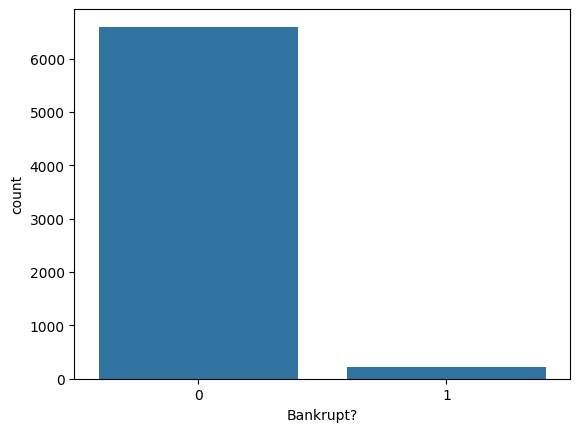

In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
# sns.barplot(df, x="Bankrupt?")
sns.countplot(df, x="Bankrupt?")
df.columns

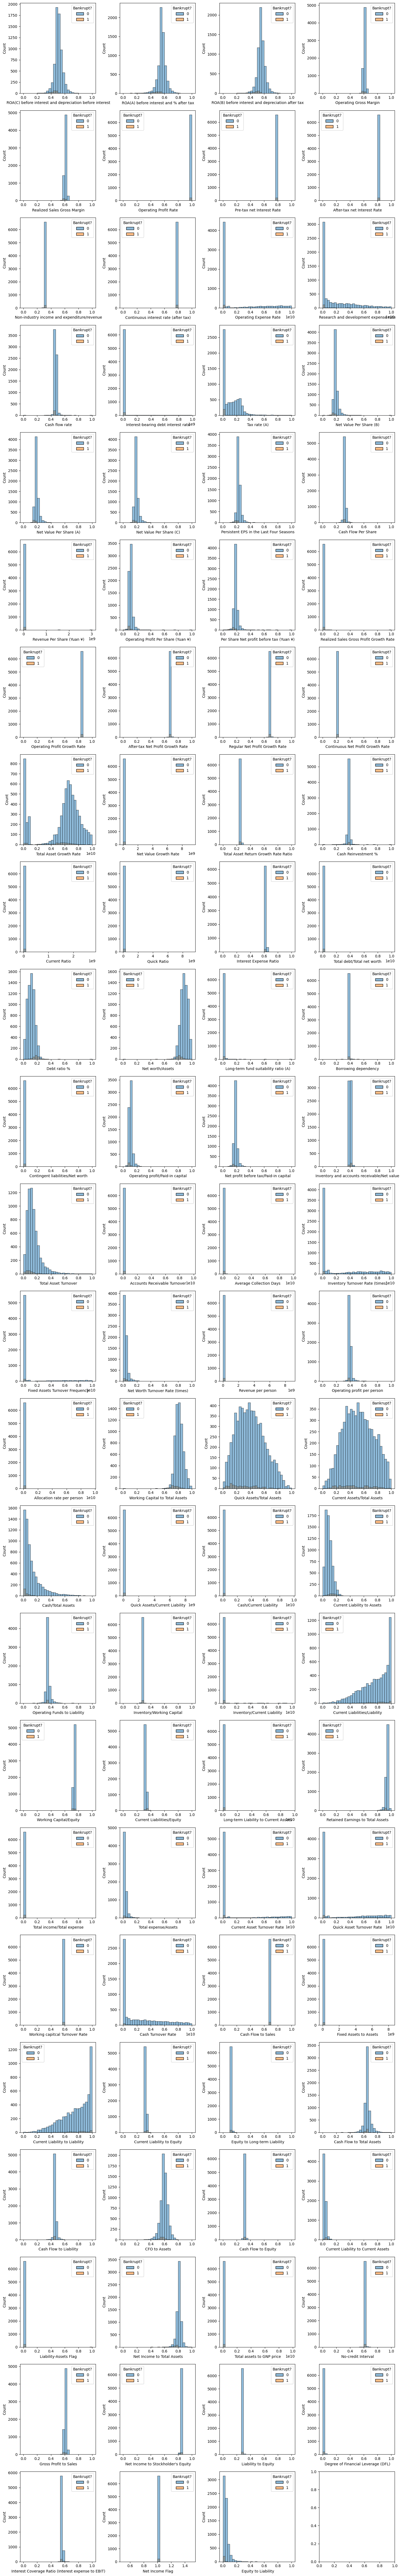

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
colomns = df.drop(columns="Bankrupt?").columns

row = (len(colomns) + 3) // 4
colomn = 4

fig, axes = plt.subplots(nrows=row, ncols=colomn, figsize=(15, 4 * row))

for x, y in zip(colomns, axes.flatten()):
    sns.histplot(df, x=x, hue="Bankrupt?", bins=30, ax=y)

plt.tight_layout()
plt.show()
# sns.histplot(df,x="Bankrupt?",y=" ROA(C) before interest and depreciation before interest")


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df.columns[df.isnull().any()]


Index([], dtype='object')

In [6]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [29]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
from sklearn.model_selection import train_test_split
X = df.drop(columns="Bankrupt?")
y = df["Bankrupt?"]

X_train,X_test,Y_train,Y_test = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)



(5455, 95)
(1364, 95)
(5455,)
(1364,)


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [32]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
from sklearn.tree import DecisionTreeClassifier

model_gini = DecisionTreeClassifier(criterion="gini")
model_gini.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_gini = model_gini.predict(X_test)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [35]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.

model_entropy = DecisionTreeClassifier(criterion="entropy")
model_entropy.fit(X_train,Y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_entropy = model_entropy.predict(X_test)

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [38]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
max_depths = [1, 2, 3, 5, 10, None]

models = {}

for depth in max_depths:
    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, Y_train)
    models[depth] = model

In [40]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
from sklearn.metrics import accuracy_score

for depth, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(Y_test, y_pred)
    
    print("max_depth =", depth)
    print("Accuracy =", accuracy)
    print()

max_depth = 1
Accuracy = 0.967741935483871

max_depth = 2
Accuracy = 0.9699413489736071

max_depth = 3
Accuracy = 0.9699413489736071

max_depth = 5
Accuracy = 0.968475073313783

max_depth = 10
Accuracy = 0.9604105571847508

max_depth = None
Accuracy = 0.9604105571847508



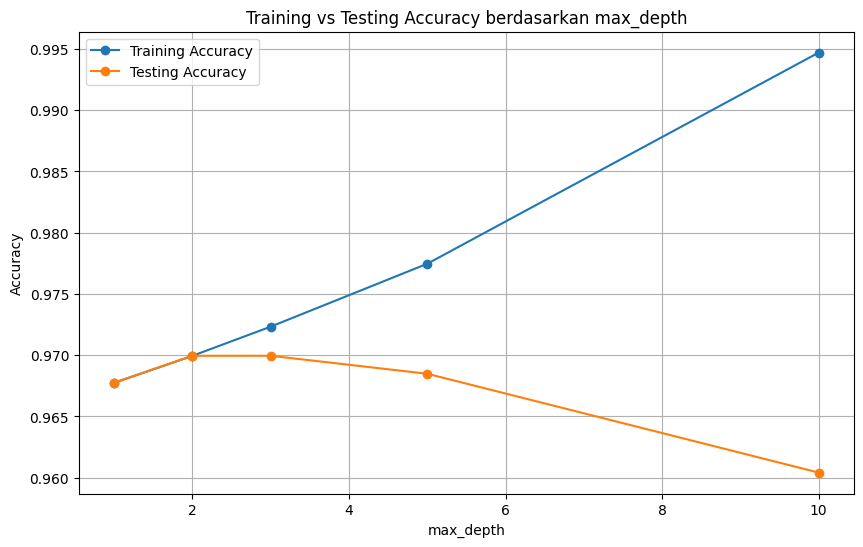

In [42]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
from sklearn.metrics import accuracy_score


train_accuracy = []
test_accuracy = []

for depth, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_accuracy.append(accuracy_score(Y_train, y_train_pred))
    test_accuracy.append(accuracy_score(Y_test, y_test_pred))

plt.figure(figsize=(10, 6))

plt.plot(max_depths, train_accuracy, marker="o", label="Training Accuracy")
plt.plot(max_depths, test_accuracy, marker="o", label="Testing Accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy berdasarkan max_depth")
plt.legend()
plt.grid()
plt.show()

# 4. Evaluasi Model

In [43]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

y_pred_gini = model_gini.predict(X_test)
y_pred_entropy = model_entropy.predict(X_test)

hasil = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Gini": [
        accuracy_score(Y_test, y_pred_gini),
        precision_score(Y_test, y_pred_gini),
        recall_score(Y_test, y_pred_gini),
        f1_score(Y_test, y_pred_gini)
    ],
    "Entropy": [
        accuracy_score(Y_test, y_pred_entropy),
        precision_score(Y_test, y_pred_entropy),
        recall_score(Y_test, y_pred_entropy),
        f1_score(Y_test, y_pred_entropy)
    ]
})

hasil

,Metric,Gini,Entropy
0,Accuracy,0.960411,0.957478
1,Precision,0.386364,0.325000
2,Recall,0.386364,0.295455
3,F1-Score,0.386364,0.309524


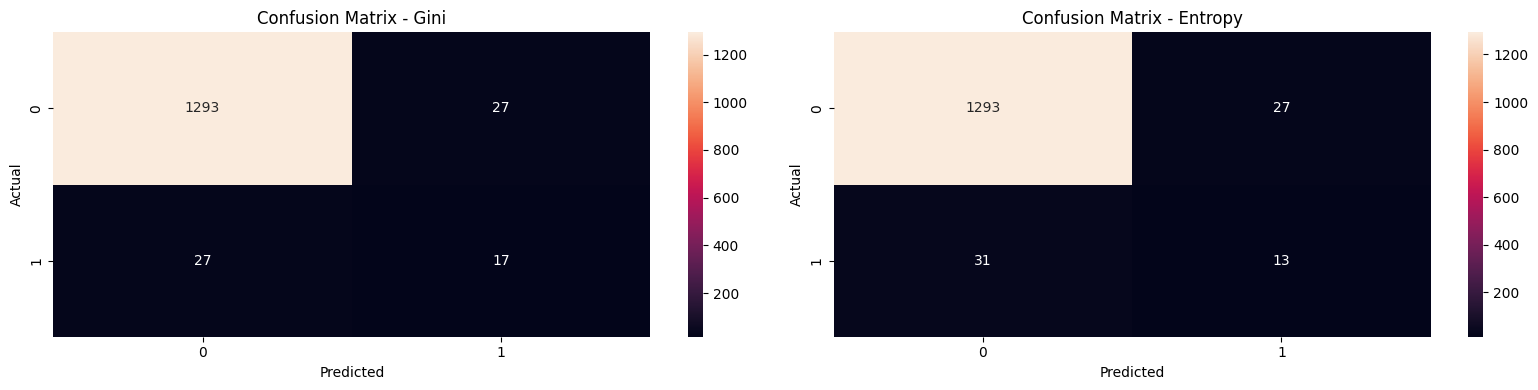

In [45]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
from sklearn.metrics import confusion_matrix

y_pred_gini = model_gini.predict(X_test)
y_pred_entropy = model_entropy.predict(X_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

cm_gini = confusion_matrix(Y_test, y_pred_gini)
cm_entropy = confusion_matrix(Y_test, y_pred_entropy)

sns.heatmap(cm_gini, annot=True, fmt="d", ax=axes[0])
axes[0].set_title("Confusion Matrix - Gini")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_entropy, annot=True, fmt="d", ax=axes[1])
axes[1].set_title("Confusion Matrix - Entropy")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

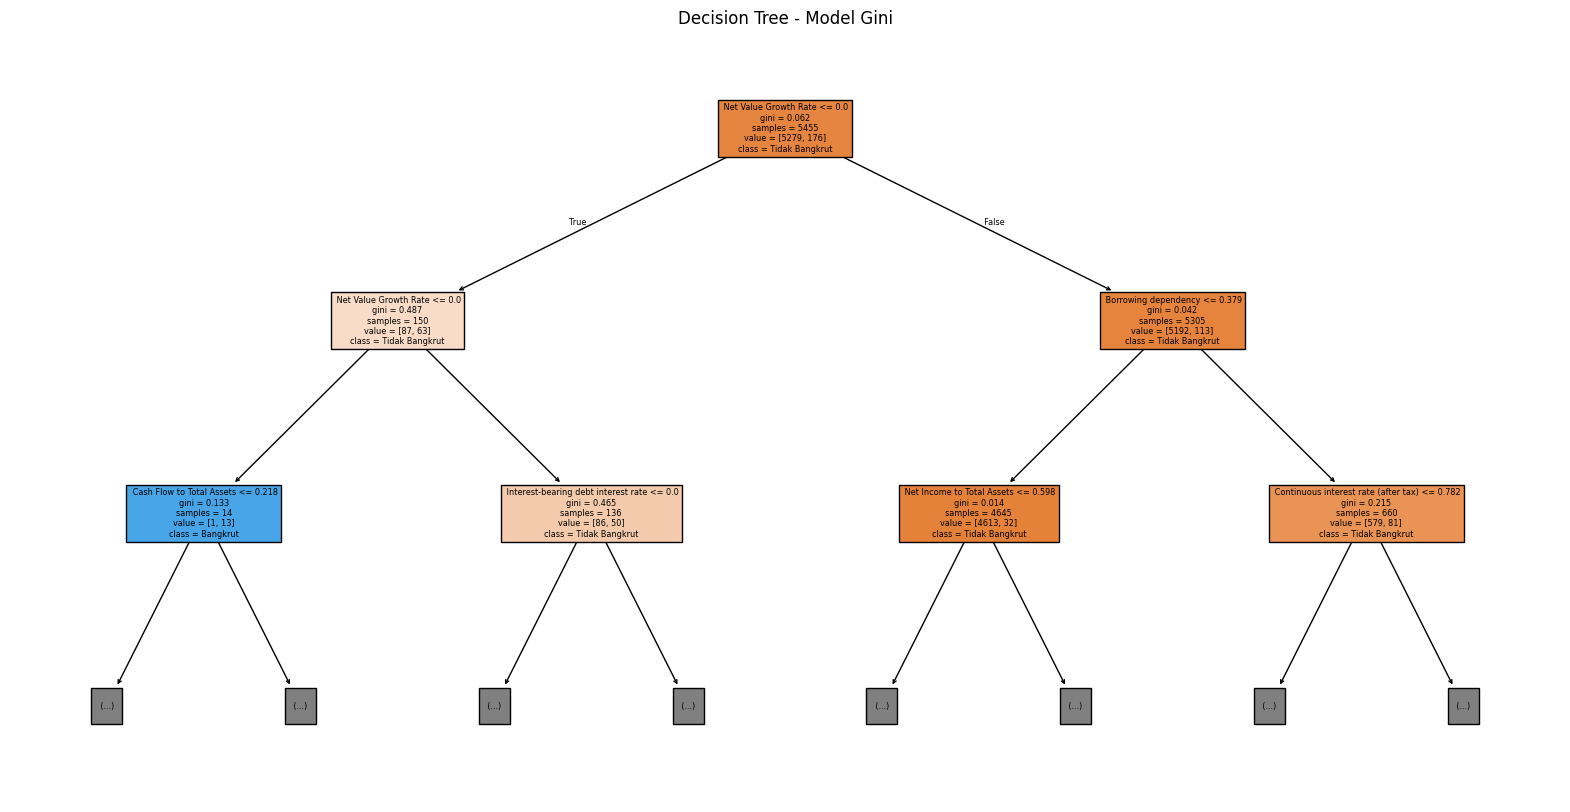

In [47]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    model_gini,
    max_depth=2,
    feature_names=X_train.columns,
    class_names=["Tidak Bangkrut", "Bangkrut"],
    filled=True
)

plt.title("Decision Tree - Model Gini")
plt.show()

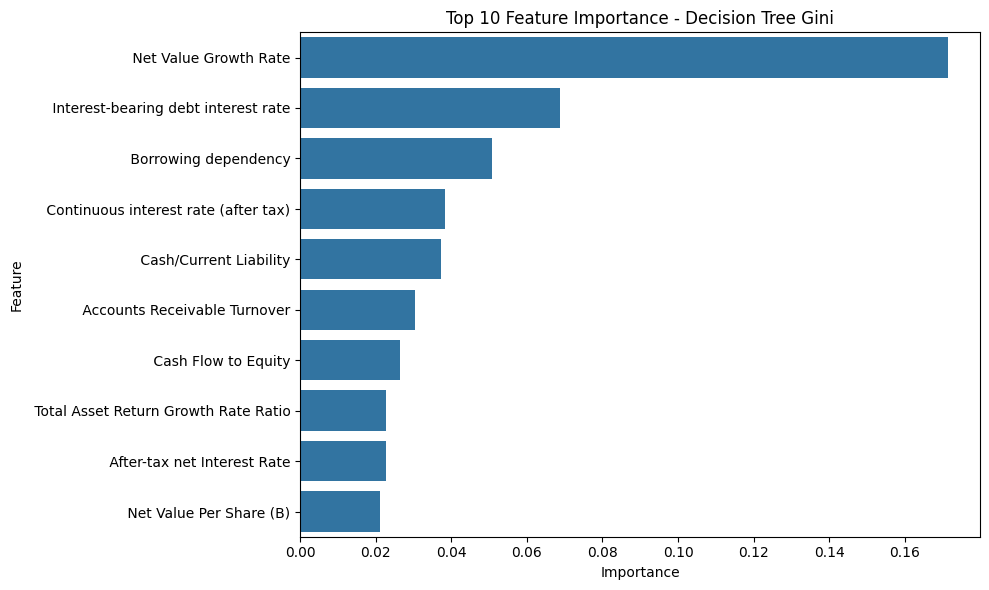

In [49]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_gini.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance - Decision Tree Gini")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

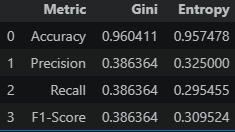

- Performa Decision Tree dengan kriteria Gini dan Entropy tidak jauh berbeda atau tidak signifikan, bisa dilihat dari tabel perbandingan performa, hal ini karena keduanya sama sama mengukur tingkat kemurnian, walau rumusnya beda namun metode pendekatannya sama sama mengukur tingkat kemurnian.

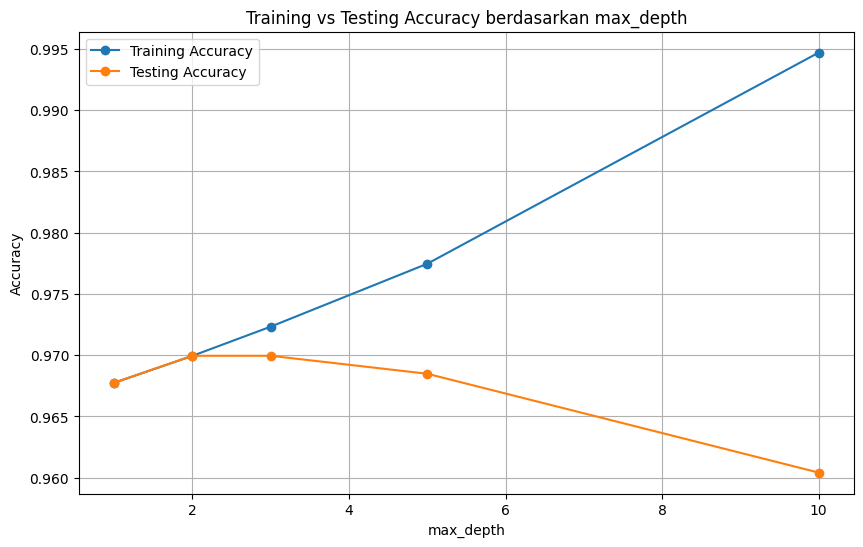

- Dari grafik training vs test accuracy diatas, ditemukan bahwa pada max_depth = 4 model mulai terlihat gejala overfitting, yang dimana akurasi pada training menjadi lebih baik tetapi hasil test akurasi justru menurun, yang merupakan ciri ciri overfitting dimana data terlalu menyesuaikan dengan data training namun terlalu mengerucut pada data training sehingga jika diberi data test yang baru model tidak bisa menyimpulkan dengan general kelompoknya sehingga test akurasi menurun

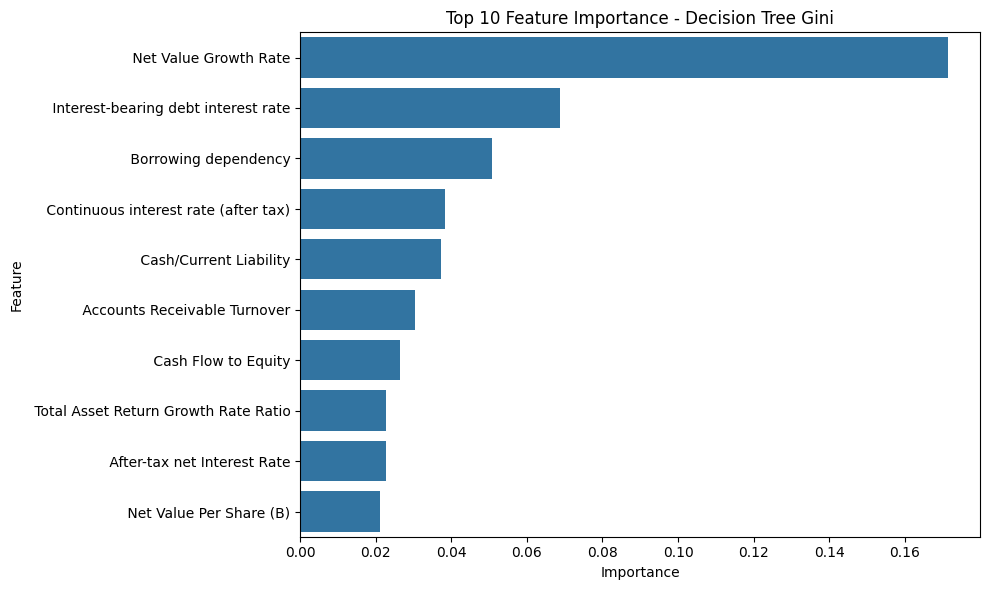

- Fitur yang paling berpengaruh terhadap prediksi model yaitu Net Value Growth Rate, Interest-Bearing Debt Interest Rate, Borrowing Depedency, Continous Interest Rate, dan Cash or Current Liability

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

# Kesimpulan

- Perbedaan performa pada gini dan entropy tidak signifikan karena sama sama menggunakan metode impurity atau tingkat kemurnian data.
- Analisis akurasi train vs test perlu dilakukan agar kita bisa menganalisa max_depth berapa model menjadi overfit, sehingga bisa memilih max_depth optimal.
- Pada data yang dilakukan test, fitur yang paling berpengaruh terhadap prediksi model yaitu Net Value Growth Rate, Interest-Bearing Debt Interest Rate, Borrowing Depedency, Continous Interest Rate, dan Cash or Current Liability

# Saran

- Bisa mencoba lebih banyak model sebagai perbandingan performa
- Bisa mencoba hyperparameter lain agar mendapat hasil maksimal
- Bisa mengolah data terlebih dahulu secara outlier dll agar mendapat hasil optimal